In [29]:
%load_ext autoreload
%autoreload 2
%xmode verbose

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload
Exception reporting mode: Verbose


In [37]:
import numpy
from ExoRM import read_rm_data, load_model, ForecasterRM, preprocess_data
import matplotlib.pyplot as plot

data = read_rm_data()
data = preprocess_data(data)
data

,radius,mass,density
0,18.647000,2543.000000,0.392211
1,16.140960,4417.837000,1.050562
2,1.910000,8.080000,1.159608
3,4.203375,57.209400,0.770323
4,3.240000,13.600000,0.399856
...,...,...,...
1488,15.356304,225.658169,0.062315
1489,13.787046,7024.007795,2.680225
1490,11.130518,6356.568140,4.609742
1491,18.494850,2224.810000,0.351674


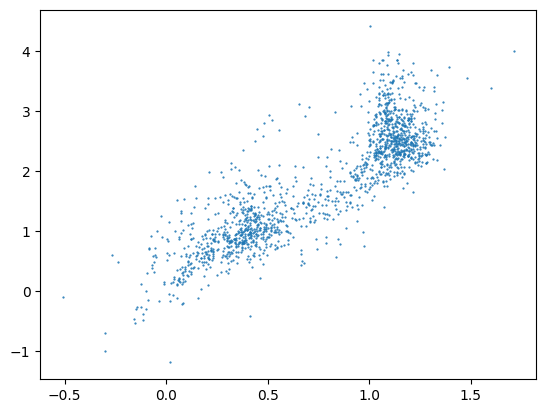

In [41]:
x = data['radius']
y = data['mass']

x = numpy.log10(x)
y = numpy.log10(y)

plot.scatter(x, y, s = 0.3)

In [42]:
import numpy

model = load_model()

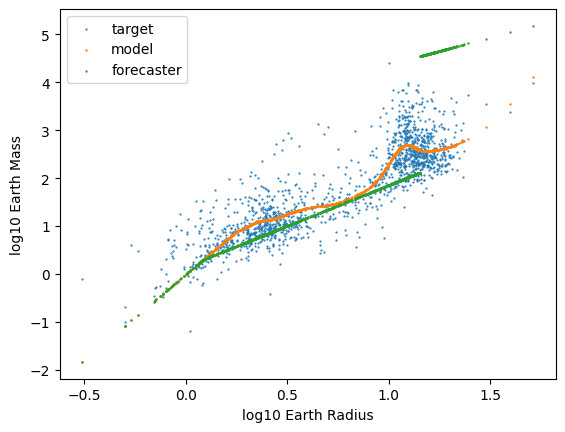

In [43]:
m = model(x)

m2 = ForecasterRM.forecaster(x)
# m3 = numpy.log10(m3) # simplified chen and kipping
plot.scatter(x, y, s = 0.3)
plot.scatter(x, m, s = 0.5)
plot.scatter(x, m2, s = 0.5)

plot.legend(['target', 'model', 'forecaster'])
plot.xlabel('log10 Earth Radius')
plot.ylabel('log10 Earth Mass')
# plot.xlim(-0.25, 1.5)
# plot.ylim(-1, 5)
plot.show()

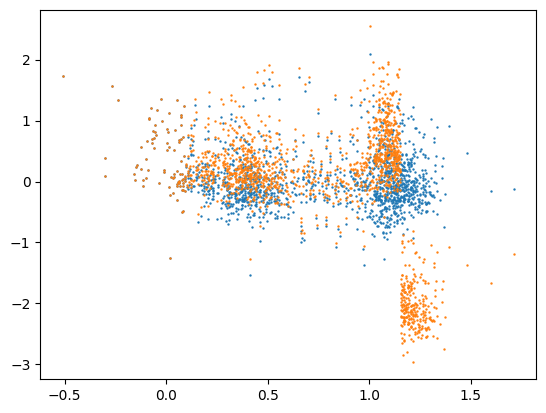

In [44]:
r = y - m
r2 = y - m2
plot.scatter(x, r, s = 0.5)
plot.scatter(x, r2, s = 0.5)
plot.show()

In [45]:
print(numpy.std(r))
print(numpy.std(r2))

0.4480485693699388
1.0284002188504964


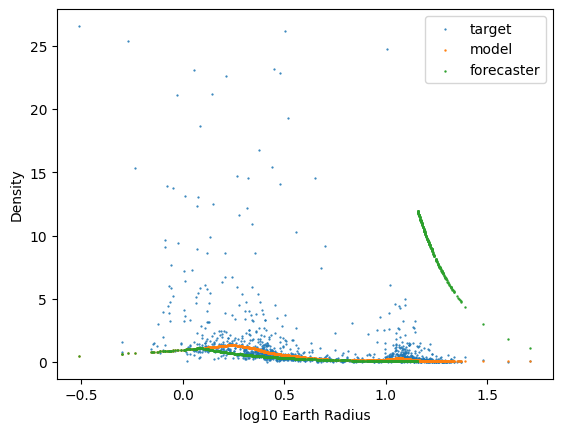

In [46]:
plot.scatter(x, (10 ** y) / ((10 ** x) ** 3), s = 0.3)
plot.scatter(x, (10 ** m) / ((10 ** x) ** 3), s = 0.5)
plot.scatter(x, (10 ** m2) / ((10 ** x) ** 3), s = 0.5)

plot.legend(['target', 'model', 'forecaster'])
plot.xlabel('log10 Earth Radius')
plot.ylabel('Density')
# plot.xlim(-0.25, 1.5)
# plot.ylim(-1, 5)
plot.show()